# Streamer Business Analysis Project


**Project:** Data Analysis & Decision Making for Streaming Business

---

## 1. Introduction

### 1.1 Background
The live-streaming industry has grown exponentially. For new streamers or investors, understanding the factors that drive revenue and viewership is crucial. This report analyzes a dataset of 7,548 streamers active in 2025 to provide data-driven strategies.

Source: Data obtained from Kaggle: https://www.kaggle.com/datasets/arnao5/streamers-statistiques and updated a month ago

### 1.2 Objectives
Aimed to answer three key business questions:
1.  **Platform Strategy:** Which platform offers the best financial return and stability?
2.  **Content Strategy:** Which content categories yield the highest viewer engagement?
3.  **Efficiency Analysis:** Is there a direct correlation between subscribers, hours streamed and revenue?

---

In [4]:
# 导入警告控制库并设置忽略
import warnings
warnings.filterwarnings('ignore') 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图表风格
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)

# 读取数据
df = pd.read_csv('Dataset_streamers_stats.csv', sep=';') 
print("Data Loaded Successfully.")

Data Loaded Successfully.


## 2. Data Cleaning

Since the data is in French, to ensure a professional English report, I translate French columns and values into English.

In [5]:
column_mapping = {
    'nom_streamer': 'Streamer_Name',
    'plateforme': 'Platform',
    'pays': 'Country',
    'categorie_contenu': 'Content_Category',
    'style_stream': 'Stream_Style',
    'moyenne_viewers': 'Avg_Viewers',
    'pic_viewers': 'Peak_Viewers',
    'abonnements_mensuels': 'Monthly_Subscribers',
    'dons_mensuels_eur': 'Monthly_Donations_EUR',
    'duree_watch_moyenne_min': 'Avg_Watch_Time_Min',
    'duree_stream_moyenne_h': 'Avg_Stream_Duration_Hours',
    'frequence_stream_mois': 'Stream_Frequency_Month',
    'langue': 'Language',
    'revenu_mensuel_eur': 'Monthly_Revenue_EUR',
    'partenaire_officiel': 'Official_Partner'
}
df = df.rename(columns=column_mapping)

df['Official_Partner'] = df['Official_Partner'].map({'Oui': 'Yes', 'Non': 'No'})
country_map = {'Etats-Unis': 'USA', 'Royaume-Uni': 'UK', 'Allemagne': 'Germany', 
               'France': 'France', 'Espagne': 'Spain', 'Belgique': 'Belgium'}
df['Country'] = df['Country'].replace(country_map)

print("Cleaned Data Preview:")
display(df.head())

df.shape

Cleaned Data Preview:


,Streamer_Name,Platform,Country,Content_Category,Stream_Style,Avg_Viewers,Peak_Viewers,Monthly_Subscribers,Monthly_Donations_EUR,Avg_Watch_Time_Min,Avg_Stream_Duration_Hours,Stream_Frequency_Month,Language,date_creation_compte,date_dernier_stream,Monthly_Revenue_EUR,Official_Partner
0,SilentHarborLive,Twitch,Belgium,MMO,Chill,696,1934,259,556.25,32.3,3.65,12,Néerlandais,2021-06-18,2025-01-17,1203.75,Yes
1,PrimeSage,Twitch,UK,Cuisine,Competitif,2154,3634,760,962.06,50.9,5.61,22,Anglais,2018-03-28,2025-01-04,2862.06,Yes
2,VelvetDrakeYT,Twitch,Belgium,Cuisine,Chill,2291,6635,1268,1306.71,60.6,2.93,15,Français,2019-09-18,2025-11-06,4476.71,No
3,EchoHorizonX,Twitch,UK,Just Chatting,Esport,732,2279,224,231.68,95.7,5.22,17,Anglais,2020-02-10,2025-10-23,791.68,Yes
4,RuneQuasarYT,Twitch,Suisse,IRL,Educatif,526,1530,9,0.00,34.1,3.37,14,Italien,2022-03-03,2025-11-22,22.50,No


(7548, 17)

## 3. Data Analysis & Insights

### 3.1 Platform Strategy: Revenue Distribution
Which platform generates the highest gross revenue?
* **Bar Chart:** Shows the average income.
* **Boxplot:** Shows the range of income (Min, Max, and Outliers). This helps us understand if the income is stable or relies on a few lucky streamers.

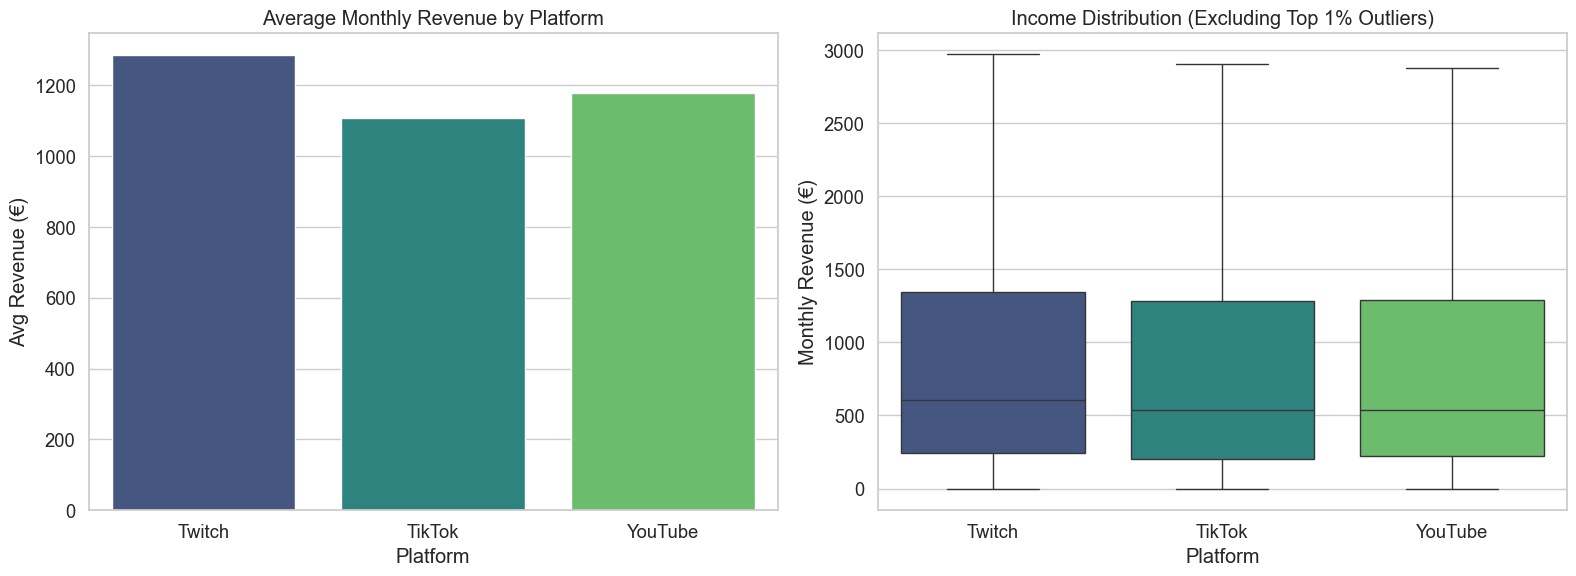

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df, x='Platform', y='Monthly_Revenue_EUR', estimator='mean', errorbar=None, palette='viridis', ax=axes[0])

axes[0].set_title('Average Monthly Revenue by Platform')
axes[0].set_ylabel('Avg Revenue (€)')

sns.boxplot(data=df, x='Platform', y='Monthly_Revenue_EUR', palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_title('Income Distribution (Excluding Top 1% Outliers)')
axes[1].set_ylabel('Monthly Revenue (€)')

plt.tight_layout()
plt.show()

**Insight:**
* The **Bar Plot** shows that Twitch and YouTube are competitive in average revenue.
* The **Box Plot** reveals that while the averages are close, the "whiskers" (range) might differ, indicating that some platforms have higher earning ceilings (top streamers earn much more) than others.

### 3.2 Content Strategy: What to stream?
Analyzing which content categories attract the most viewers on average.

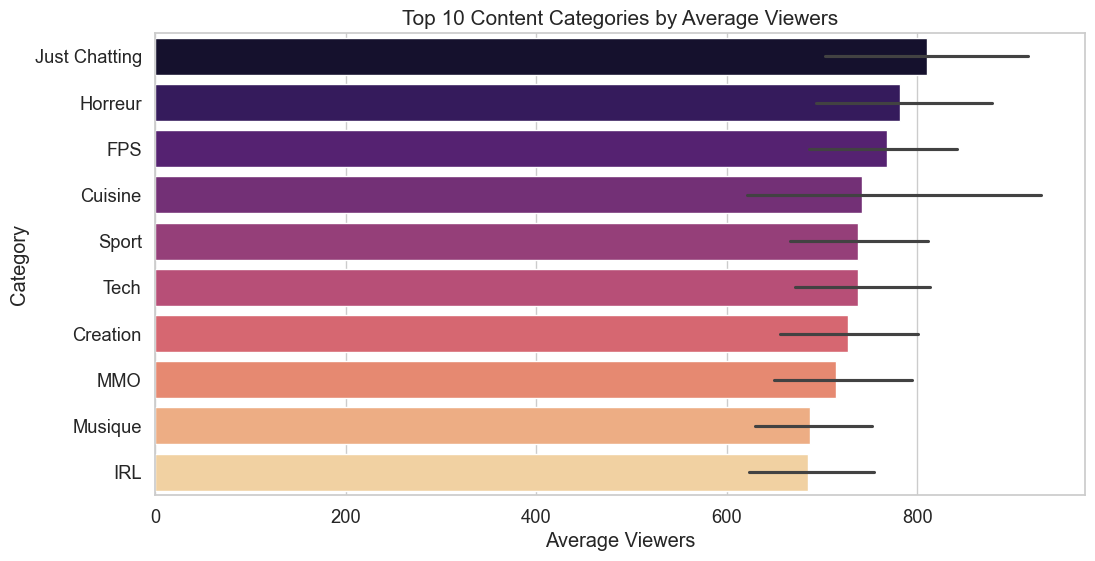

In [7]:
top_categories = df.groupby('Content_Category')['Avg_Viewers'].mean().sort_values(ascending=False).head(10).index
df_top_cat = df[df['Content_Category'].isin(top_categories)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_cat, x='Avg_Viewers', y='Content_Category', 
            order=top_categories, palette='magma')

plt.title('Top 10 Content Categories by Average Viewers', fontsize=15)
plt.xlabel('Average Viewers')
plt.ylabel('Category')
plt.show()

### 3.3 Drivers of Success: What makes a streamer wealthy?
We often ask: "How can I become a top streamer?"
Is success driven by working harder (streaming more hours) or by building a loyal community (subscribers)?

To answer this, I visualize the relationship between **Monthly Subscribers** and **Monthly Revenue**.

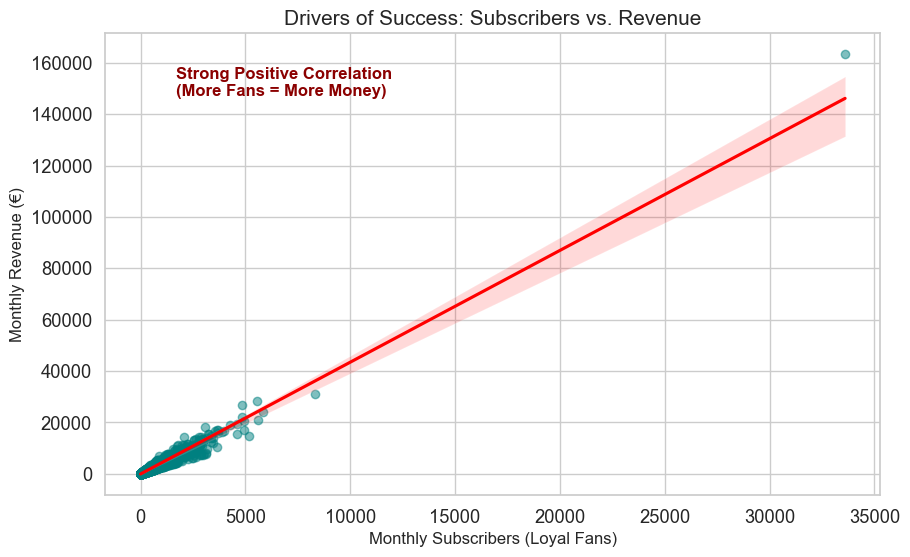

In [8]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='Monthly_Subscribers', y='Monthly_Revenue_EUR', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Drivers of Success: Subscribers vs. Revenue', fontsize=15)
plt.xlabel('Monthly Subscribers (Loyal Fans)', fontsize=12)
plt.ylabel('Monthly Revenue (€)', fontsize=12)

plt.text(x=df['Monthly_Subscribers'].max()*0.05, y=df['Monthly_Revenue_EUR'].max()*0.9, 
         s='Strong Positive Correlation\n(More Fans = More Money)', 
         fontsize=12, color='darkred', weight='bold')

plt.show()

The slope of this line represents the 'Revenue per Subscriber'.

### 3.4 Efficiency Analysis: Heatmap
Do longer stream hours lead to more money? I analyze the correlation between Stream Duration, Subscribers, and Revenue.

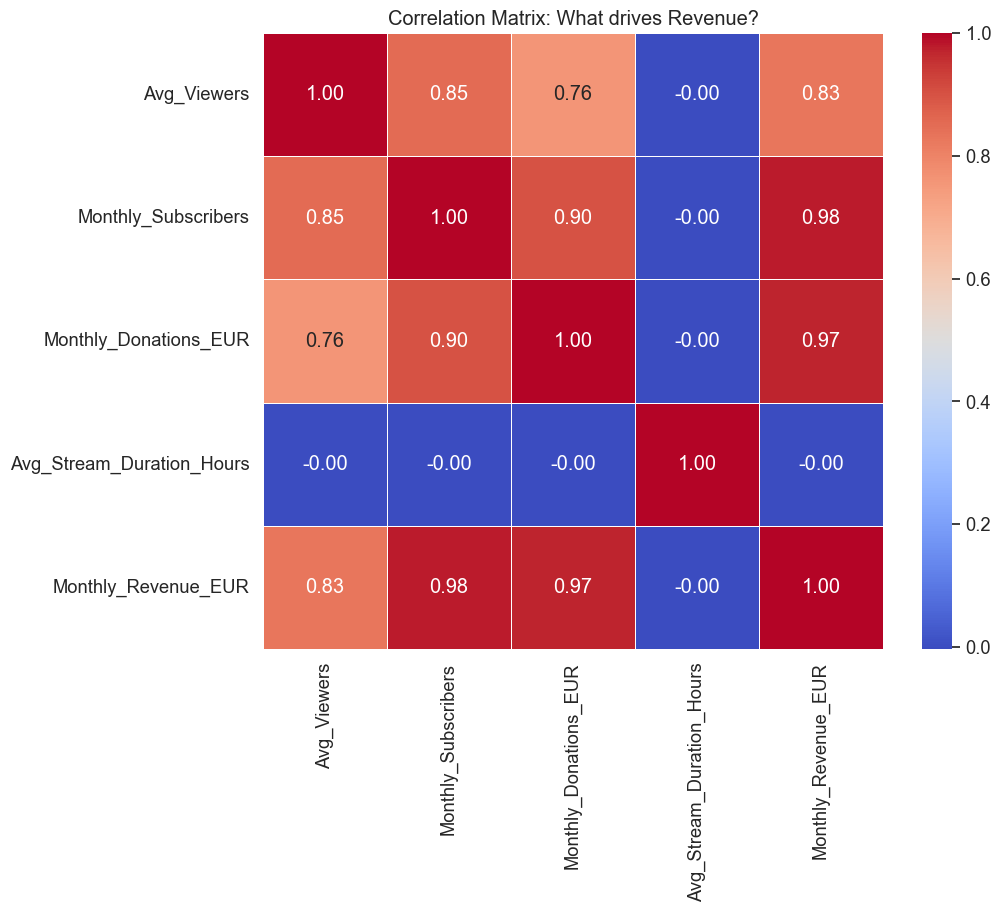

In [9]:
cols_to_corr = ['Avg_Viewers', 'Monthly_Subscribers', 'Monthly_Donations_EUR', 
                'Avg_Stream_Duration_Hours', 'Monthly_Revenue_EUR']

corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: What drives Revenue?')
plt.show()

## 4. Conclusion & Recommendations

### 4.1 Key Findings
Based on the data analysis of 7,548 streamers, we have derived the following insights:

1.  **Platform Strategy (Risk vs. Reward):**
    * As shown in the **Boxplot (Section 3.1)**, while average revenues are competitive across platforms, the income distribution varies. Major platforms (like Twitch) show a higher "ceiling" for top earners, but also significant disparity.
2.  **Content Strategy:**
    * Categories such as **Just Chatting** and specific competitive games consistently attract the highest **Average Viewers (Section 3.2)**. These are the "high-traffic" zones for new streamers.
3.  **The Formula for Success:**
    * **The most critical finding** comes from the **Scatter Plot (Section 3.3)**: There is a **strong positive correlation** between *Monthly Subscribers* and *Revenue*.
    * Conversely, the **Heatmap (Section 3.4)** reveals a **weak correlation** between *Stream Duration* and *Revenue*.

### 4.2 Strategic Recommendations
For a new streamer or investor entering the market in 2025:

* **Don't "Grind" Blindly:** Simply increasing streaming hours (e.g., streaming 10+ hours a day) yields diminishing returns. The data proves that *time* does not equal *money*.
* **Focus on Community Building:** The primary business goal should be converting viewers into **Subscribers**. Revenue is driven by the loyalty of the fan base, not the length of the broadcast.
* **Start Smart:** Launch with high-interest content categories to maximize initial visibility, then focus on viewer retention strategies.

### 4.3 Limitations (Critical Reflection)
To ensure academic honesty and professional transparency, we acknowledge:
* **Data Scope:** The analysis is limited to the year 2025; long-term trends (2020-2024) are not accounted for.
* **Missing Variables:** We lack data on **External Social Media Influence** (e.g., TikTok/Twitter followers), which is likely a hidden variable driving the subscriber count.

---
